<a href="https://colab.research.google.com/github/krishu-shrestha/Graph-Analytics-Network-Science-Techniques/blob/main/Week_6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# Install required libraries
!pip install networkx matplotlib pandas numpy -q

In [42]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

In [43]:
# downloading the dataset
# Download the Email-Eu-core dataset
!wget -q https://snap.stanford.edu/data/email-Eu-core.txt.gz

In [44]:
!ls -lh email-Eu-core.txt.gz

-rw-r--r-- 1 root root 78K Oct  4 02:16 email-Eu-core.txt.gz


In [45]:
# Load the edge list
edges = pd.read_csv(
    "email-Eu-core.txt.gz",
    sep=" ",
    header=None,
    names=["source", "target"]
)

edges.head()

,source,target
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [46]:
print("Number of edges:", len(edges))
print("Number of unique source nodes:", edges["source"].nunique())
print("Number of unique target nodes:", edges["target"].nunique())

Number of edges: 25571
Number of unique source nodes: 868
Number of unique target nodes: 991


In [47]:
# creating the network x graph
G = nx.DiGraph()

G.add_edges_from(edges.itertuples(index=False, name=None))

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 1005
Number of edges: 25571


In [48]:
#basic graph statistics
print("Graph Type:", type(G).__name__)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

density = nx.density(G)

print("Graph Density:", round(density, 4))

Graph Type: DiGraph
Nodes: 1005
Edges: 25571
Graph Density: 0.0253


In [49]:
# degree information
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

print("Highest in-degree node:",
      max(in_degree, key=in_degree.get),
      "with",
      max(in_degree.values()),
      "incoming connections")

print("Highest out-degree node:",
      max(out_degree, key=out_degree.get),
      "with",
      max(out_degree.values()),
      "outgoing connections")

Highest in-degree node: 160 with 212 incoming connections
Highest out-degree node: 160 with 334 outgoing connections


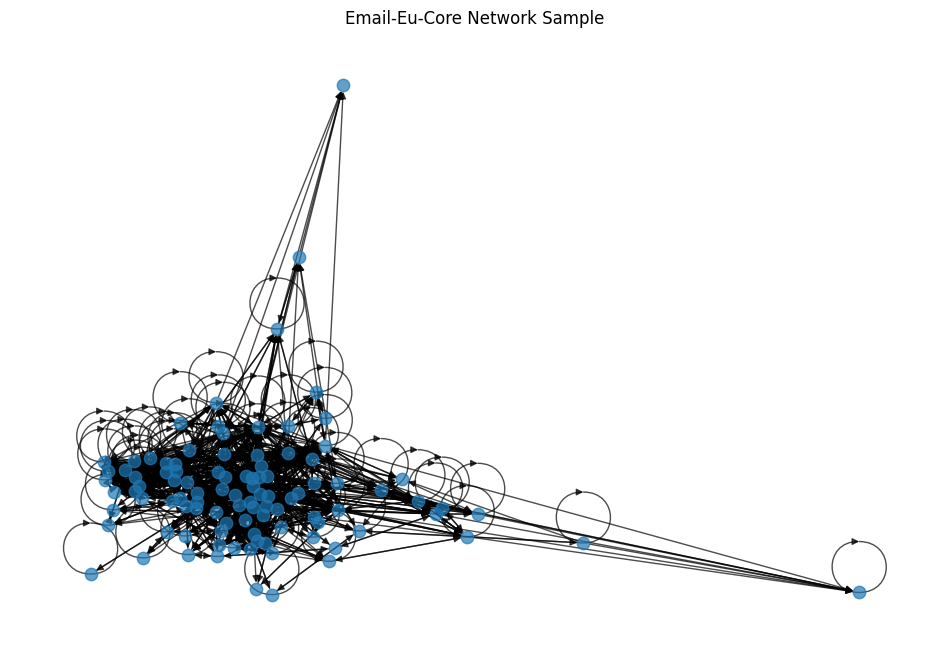

In [50]:
# basic network visualizaiton
# Select the first 100 nodes for visualization
sample_nodes = list(G.nodes())[:100]

G_sample = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G_sample, seed=42)

nx.draw_networkx(
    G_sample,
    pos,
    node_size=80,
    with_labels=False,
    arrows=True,
    alpha=0.7
)

plt.title("Email-Eu-Core Network Sample")
plt.axis("off")
plt.show()

In [51]:
# choosing a starting node
start_node = max(out_degree, key=out_degree.get)

print("Starting node:", start_node)
print("Outgoing connections:", out_degree[start_node])

Starting node: 160
Outgoing connections: 334


In [52]:
# breadth first search manually
def bfs_traversal(graph, start):
    visited = set()
    queue = deque([start])
    traversal_order = []

    visited.add(start)

    while queue:
        node = queue.popleft()
        traversal_order.append(node)

        for neighbor in graph.successors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return traversal_order


bfs_order = bfs_traversal(G, start_node)

print("BFS traversal completed.")
print("Number of nodes reached:", len(bfs_order))
print("First 20 nodes visited:")
print(bfs_order[:20])

BFS traversal completed.
Number of nodes reached: 965
First 20 nodes visited:
[160, 161, 28, 23, 187, 190, 113, 263, 405, 18, 284, 362, 300, 180, 45, 321, 61, 319, 338, 314]


In [53]:
# bfs using network
nx_bfs_order = list(nx.bfs_tree(G, source=start_node).nodes())

print("Our BFS:", bfs_order[:20])
print("NetworkX BFS:", nx_bfs_order[:20])

print("Same traversal:", bfs_order == nx_bfs_order)

Our BFS: [160, 161, 28, 23, 187, 190, 113, 263, 405, 18, 284, 362, 300, 180, 45, 321, 61, 319, 338, 314]
NetworkX BFS: [160, 161, 28, 23, 187, 190, 113, 263, 405, 18, 284, 362, 300, 180, 45, 321, 61, 319, 338, 314]
Same traversal: True


In [54]:
# bfs traversal levels
bfs_distances = nx.single_source_shortest_path_length(
    G,
    start_node
)

distance_df = pd.DataFrame(
    bfs_distances.items(),
    columns=["Node", "BFS_Distance"]
)

distance_df.head(20)

,Node,BFS_Distance
0,160,0
1,161,1
2,28,1
3,23,1
4,187,1
5,190,1
6,113,1
7,263,1
8,405,1
9,18,1


In [55]:
distance_counts = (
    distance_df["BFS_Distance"]
    .value_counts()
    .sort_index()
)

print(distance_counts)

BFS_Distance
0      1
1    333
2    569
3     59
4      3
Name: count, dtype: int64


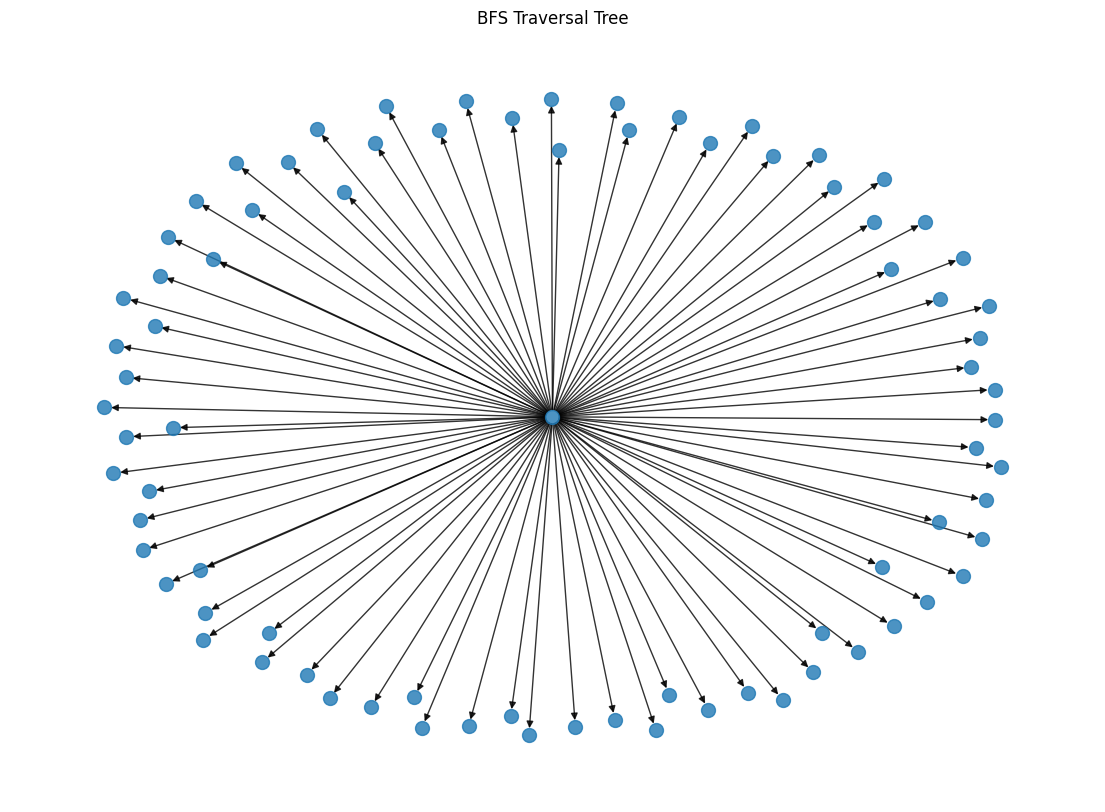

In [56]:
# visualizing bfs levels
# Create BFS tree
bfs_tree = nx.bfs_tree(G, source=start_node)

# Take first 80 nodes for visualization
bfs_nodes = list(bfs_tree.nodes())[:80]

bfs_subgraph = bfs_tree.subgraph(bfs_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(bfs_subgraph, seed=42)

nx.draw_networkx(
    bfs_subgraph,
    pos,
    node_size=100,
    with_labels=False,
    arrows=True,
    alpha=0.8
)

plt.title("BFS Traversal Tree")
plt.axis("off")
plt.show()

In [57]:
# depth first search manually
def dfs_traversal(graph, start):
    visited = set()
    traversal_order = []

    def dfs(node):
        visited.add(node)
        traversal_order.append(node)

        for neighbor in graph.successors(node):
            if neighbor not in visited:
                dfs(neighbor)

    dfs(start)

    return traversal_order


dfs_order = dfs_traversal(G, start_node)

print("DFS traversal completed.")
print("Number of nodes reached:", len(dfs_order))
print("First 20 nodes visited:")
print(dfs_order[:20])

DFS traversal completed.
Number of nodes reached: 965
First 20 nodes visited:
[160, 161, 7, 44, 362, 293, 19, 62, 63, 137, 138, 58, 57, 55, 54, 56, 59, 520, 92, 20]


In [58]:
# verifying dfs with network x
nx_dfs_order = list(nx.dfs_preorder_nodes(G, source=start_node))

print("Our DFS:", dfs_order[:20])
print("NetworkX DFS:", nx_dfs_order[:20])

print("Same traversal:", dfs_order == nx_dfs_order)

Our DFS: [160, 161, 7, 44, 362, 293, 19, 62, 63, 137, 138, 58, 57, 55, 54, 56, 59, 520, 92, 20]
NetworkX DFS: [160, 161, 7, 44, 362, 293, 19, 62, 63, 137, 138, 58, 57, 55, 54, 56, 59, 520, 92, 20]
Same traversal: True


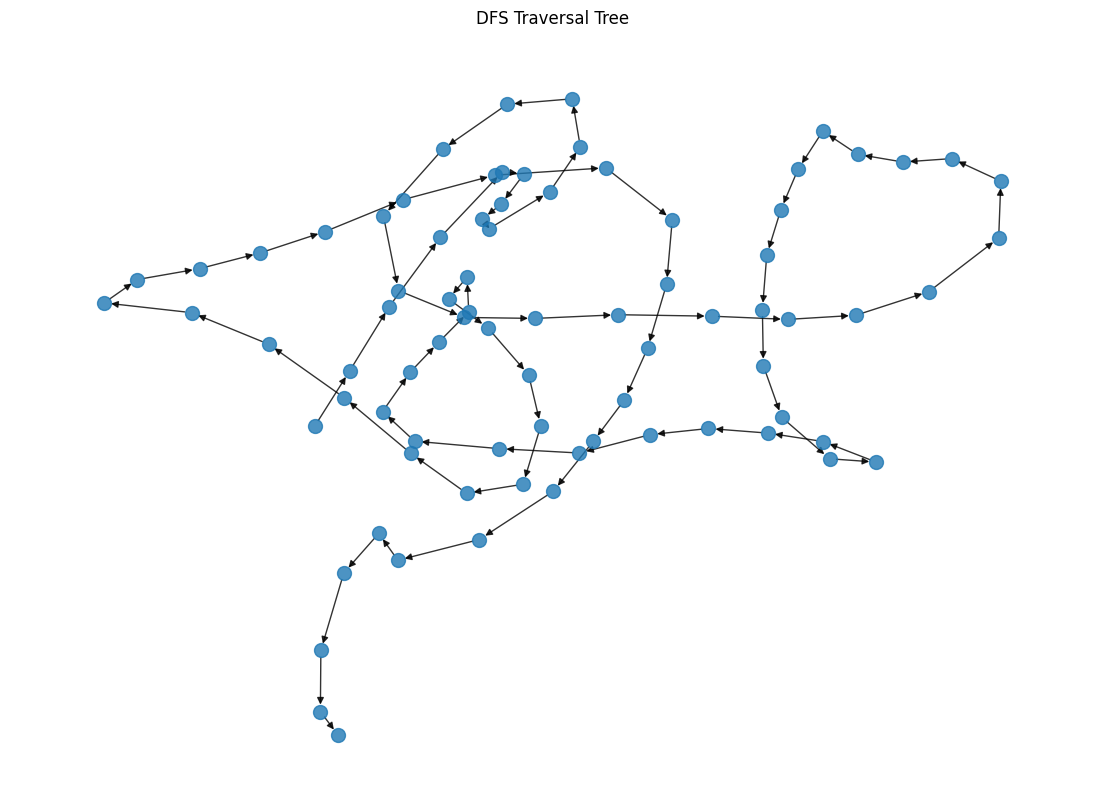

In [59]:
# creating dfs traversal tree
dfs_tree = nx.dfs_tree(G, source=start_node)

dfs_nodes = list(dfs_tree.nodes())[:80]

dfs_subgraph = dfs_tree.subgraph(dfs_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(dfs_subgraph, seed=42)

nx.draw_networkx(
    dfs_subgraph,
    pos,
    node_size=100,
    with_labels=False,
    arrows=True,
    alpha=0.8
)

plt.title("DFS Traversal Tree")
plt.axis("off")
plt.show()

In [60]:
# comparing bfs and dfs
comparison = pd.DataFrame({
    "Measure": [
        "Nodes reached by BFS",
        "Nodes reached by DFS",
        "BFS first node",
        "DFS first node",
        "BFS traversal length",
        "DFS traversal length"
    ],
    "Result": [
        len(bfs_order),
        len(dfs_order),
        bfs_order[0],
        dfs_order[0],
        len(bfs_order),
        len(dfs_order)
    ]
})

comparison

,Measure,Result
0,Nodes reached by BFS,965
1,Nodes reached by DFS,965
2,BFS first node,160
3,DFS first node,160
4,BFS traversal length,965
5,DFS traversal length,965


In [61]:
# comparing the first 30 nodes
comparison_order = pd.DataFrame({
    "Position": range(1, 31),
    "BFS_Node": bfs_order[:30],
    "DFS_Node": dfs_order[:30]
})

comparison_order

,Position,BFS_Node,DFS_Node
0,1,160,160
1,2,161,161
2,3,28,7
3,4,23,44
4,5,187,362
5,6,190,293
6,7,113,19
7,8,263,62
8,9,405,63
9,10,18,137


In [62]:
# measure traversal depth
bfs_tree_depth = nx.dag_longest_path_length(
    nx.bfs_tree(G, start_node)
)

dfs_tree_depth = nx.dag_longest_path_length(
    nx.dfs_tree(G, start_node)
)

print("BFS tree depth:", bfs_tree_depth)
print("DFS tree depth:", dfs_tree_depth)

BFS tree depth: 4
DFS tree depth: 531


In [63]:
# reachability analysis
reachable_nodes = nx.descendants(G, start_node)

print("Starting node:", start_node)
print("Reachable nodes:", len(reachable_nodes))
print(
    "Percentage of network reachable:",
    round((len(reachable_nodes) / G.number_of_nodes()) * 100, 2),
    "%"
)

Starting node: 160
Reachable nodes: 964
Percentage of network reachable: 95.92 %


In [64]:
# strongly connected
strong_components = list(nx.strongly_connected_components(G))

strong_components_sorted = sorted(
    strong_components,
    key=len,
    reverse=True
)

print("Number of strongly connected components:",
      len(strong_components_sorted))

print("Largest strongly connected component:",
      len(strong_components_sorted[0]))

Number of strongly connected components: 203
Largest strongly connected component: 803


In [65]:
largest_scc = G.subgraph(strong_components_sorted[0]).copy()

print("Largest SCC nodes:", largest_scc.number_of_nodes())
print("Largest SCC edges:", largest_scc.number_of_edges())

Largest SCC nodes: 803
Largest SCC edges: 24729


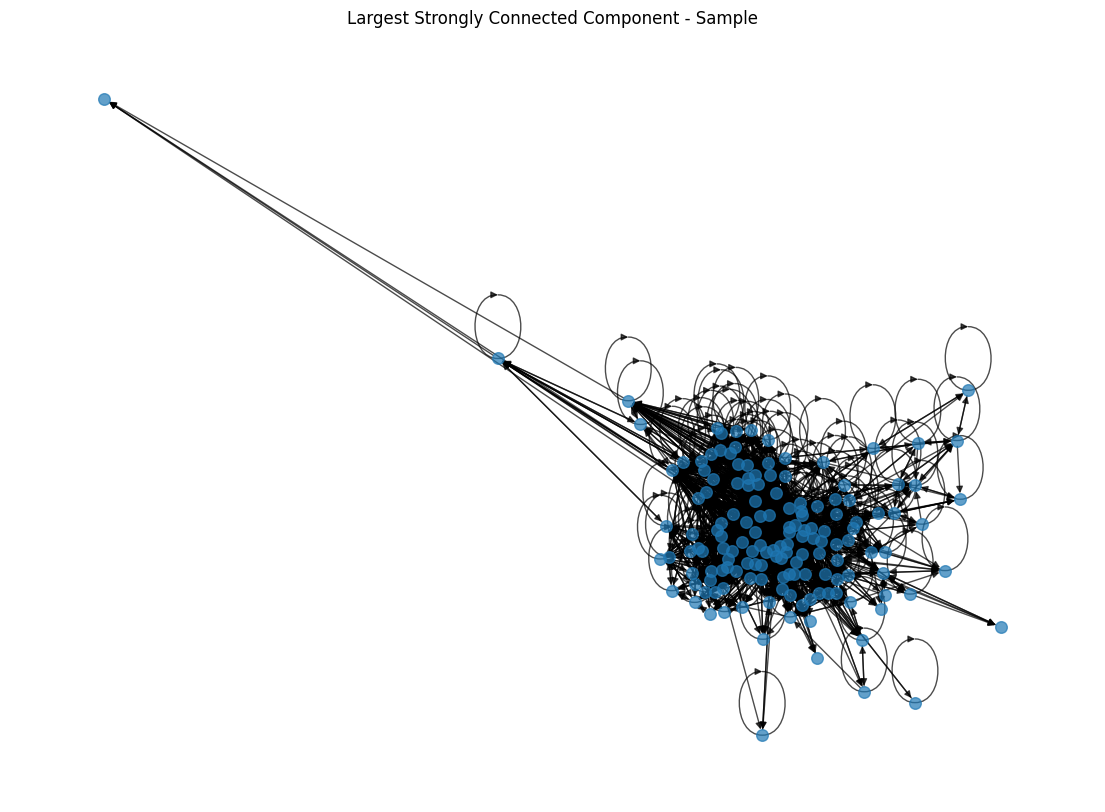

In [66]:
# visualizing the largest scc
# Sample the largest SCC if necessary
scc_nodes = list(largest_scc.nodes())[:150]

scc_sample = largest_scc.subgraph(scc_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(scc_sample, seed=42)

nx.draw_networkx(
    scc_sample,
    pos,
    node_size=70,
    with_labels=False,
    arrows=True,
    alpha=0.7
)

plt.title("Largest Strongly Connected Component - Sample")
plt.axis("off")
plt.show()

In [67]:
# final bfs vs dfs result table
final_results = pd.DataFrame({
    "Metric": [
        "Total graph nodes",
        "Total graph edges",
        "Starting node",
        "BFS nodes reached",
        "DFS nodes reached",
        "BFS tree depth",
        "DFS tree depth",
        "Largest SCC size"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        start_node,
        len(bfs_order),
        len(dfs_order),
        bfs_tree_depth,
        dfs_tree_depth,
        len(strong_components_sorted[0])
    ]
})

final_results

,Metric,Value
0,Total graph nodes,1005
1,Total graph edges,25571
2,Starting node,160
3,BFS nodes reached,965
4,DFS nodes reached,965
5,BFS tree depth,4
6,DFS tree depth,531
7,Largest SCC size,803
